# Data Exploration and Analysis

In [ ]:
# !pip install matplotlib

In [2]:
import pandas as pd
import numpy as np
import sklearn
from pathlib import Path
from copy import deepcopy
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import datetime as dt

In [3]:
# Allow full view of DataFrames and Series
pd.set_option('display.max_columns', None)  # None or 1000
# pd.set_option('display.max_rows', None)  # or 1000
pd.set_option('display.max_colwidth', None)  # or 199

In [4]:
# data integration
df = pd.read_csv('./data/transactions-1.csv')
df

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,sex,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1852389,1852389,2020-12-31 23:59:07,30560609640617,fraud_Reilly and Sons,health_fitness,43.77,Michael,Olson,M,558 Michael Estates,Luray,MO,63453,40.4931,-91.8912,519,Town planner,1966-02-13,9b1f753c79894c9f4b71f04581835ada,1388534347,39.946837,-91.333331,0
1852390,1852390,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,TX,77566,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0
1852391,1852391,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,WA,99323,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0
1852392,1852392,2020-12-31 23:59:24,4079773899158,fraud_Breitenberg LLC,travel,7.99,Eric,Preston,M,7020 Doyle Stream Apt. 951,Mesa,ID,83643,44.6255,-116.4493,129,Cartographer,1965-12-15,14392d723bb7737606b2700ac791b7aa,1388534364,44.470525,-117.080888,0


### 1) What is the distribution between fraudulent and non-fraudulent transactions?

In [5]:
df['is_fraud'].value_counts()

0    1842743
1       9651
Name: is_fraud, dtype: int64

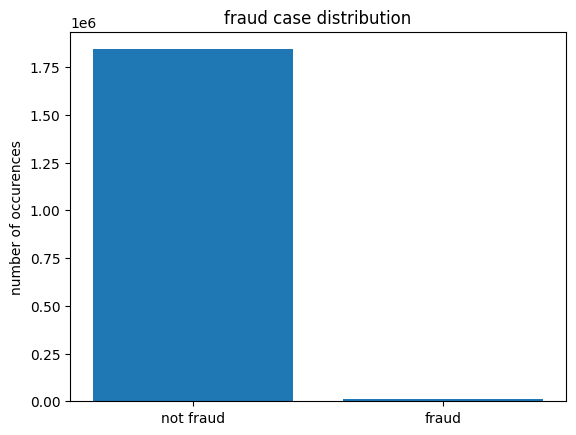

In [6]:
plt.bar(['not fraud', 'fraud'], df['is_fraud'].value_counts())
plt.ylabel("number of occurences")
plt.title("fraud case distribution")
plt.show()

**The relatively non-present bar on the right depicts the extent of the class imbalance.**

**This calls for stratified dataset splitting and metrics which capture precision and recall.**

### 2) Which age groups are more susceptible to fraudulent transactions?

In [7]:
type(df['trans_date_trans_time'][0])

str

In [8]:
type(df['dob'][0])

str

In [9]:
df['dob'] = pd.to_datetime(df['dob'])
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
diff = df['trans_date_trans_time'] - df['dob']
df['age_yrs'] = diff.apply(lambda x: abs(int(x.days / 365.2425)))

In [10]:
print(np.min(df['age_yrs']))
print(np.max(df['age_yrs']))

13
96


In [11]:
agebands = [(13, 18), (19, 29), (30, 31), (30, 39), (40, 49), (50, 59),\
            (60, 69), (70, 79), (80, 89), (90, 99)]
condprobs = []
ageticks = []
for ageband in agebands:
    condprob = len(df.loc[(df['is_fraud'] == 1) &\
        (df['age_yrs'].between(ageband[0], ageband[1]))]) /\
        len(df.loc[df['age_yrs'].between(13, 18)])
    condprobs.append(condprob)
    ageticks.append('{}-{}'.format(ageband[0], ageband[1]))
#     print('{} {}'.format(ageband, condprob))

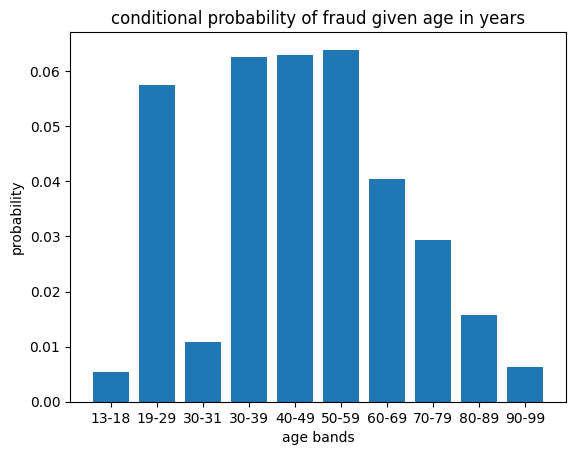

In [12]:
plt.bar(ageticks, condprobs)
plt.title('conditional probability of fraud given age in years')
plt.xlabel('age bands')
plt.ylabel('probability')
plt.show()

**While the maximum probability is under %7, it is interesting that the middle age groups tend to have more frequent cases of fraud.**

**It is also interesting that the 30-31 age group has a much lower fraud probability than the neighboring younger and older age groups.**

**This does not seem to have impact on model design.  The system, however, should allow toggling of age inputs for inference.**

### 3) If a fraudulent transaction has been committed, what is the expected number of transaction committed per day with the same victim?

In [13]:
def get_fraudsinday():
    fraudsinday = []
    for cc_num in df['cc_num'].unique():  # get the unix times of fraud per victim
        custftimes = df.loc[(df['is_fraud'] == 1) & (df['cc_num'] == cc_num),\
                           'unix_time'].to_numpy()

        # slide a 1 day window over the fraud times
        # this is the start of the window
        for i in range(0, len(custftimes) - 1):
            count = 1
            # this is the end of the window
            for j in range(i + 1, len(custftimes)):
                if custftimes[j] - custftimes[i] <= 86400:
                    count += 1
            fraudsinday.append(count)

    return fraudsinday

fraudsinday = get_fraudsinday()
print('mean fraud occurences in 24hr period following each fraud case per customer: {}'\
      .format(np.mean(fraudsinday)))
print('standard deviation: {}'.format(np.std(fraudsinday)))

mean fraud occurences in 24hr period following each fraud case per customer: 5.149279538904899
standard deviation: 2.2796350129297025


**For every occurence of fraud, there will be an average of 4.15 *additional* fraud cases within the following 24hr period.**

**This may call for a binary feature which indicates whether or not there has already been a fraud transaction for the day for the customer.**

### 4) For each purchase "category," plot the mean and standard "amt" between fraudulent transactions and non-fraudulent transactions

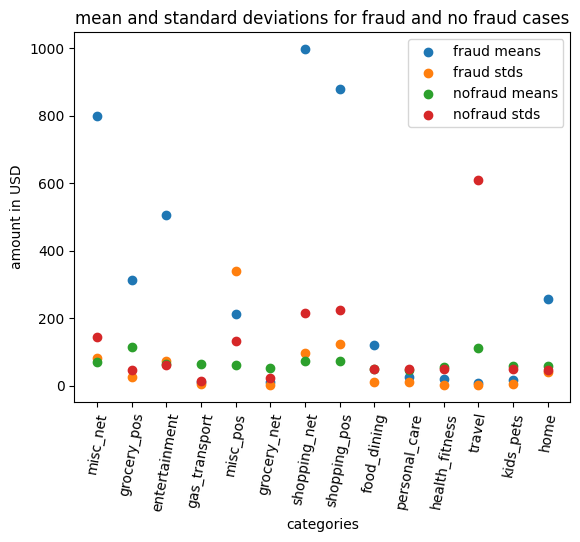

In [14]:
def plot_catfraudstats():
    categories = []
    catfraudmeans = []
    catfraudstds = []
    catnofraudmeans = []
    catnofraudstds = []
    for category in df['category'].unique():
        catfraud = df.loc[(df['is_fraud'] == 1) & (df['category'] == category),\
              'amt'].to_numpy()
        catnofraud = df.loc[(df['is_fraud'] == 0) & (df['category'] == category),\
              'amt'].to_numpy()
        categories.append(category)
        catfraudmeans.append(np.mean(catfraud))
        catfraudstds.append(np.std(catfraud))
        catnofraudmeans.append(np.mean(catnofraud))
        catnofraudstds.append(np.std(catnofraud))
        
    plt.scatter(categories, catfraudmeans)
    plt.scatter(categories, catfraudstds)
    plt.scatter(categories, catnofraudmeans)
    plt.scatter(categories, catnofraudstds)
    plt.title('mean and standard deviations for fraud and no fraud cases')
    plt.legend(['fraud means', 'fraud stds', 'nofraud means', 'nofraud stds'])
    plt.xlabel('categories')
    plt.xticks(rotation=80)
    plt.ylabel('amount in USD')
    plt.show()
    
plot_catfraudstats()

**The plot shows fraud cases being much more expensive on average (blue dots).  Non consumable material purchases, which likley constitute *shopping* purchases, had the highest costs.**  

**This does not seem to impact model design.  The system should allow toggling of purchase categories.**

### 5) What is the distribution between time transactions between fraudulent transactions and non-fraudulent transactions? What is the most likely time of a fraudulent transaction?

In [15]:
fraudunixtimes = df.loc[df['is_fraud'] == 1, 'unix_time'].reset_index(drop=True)
timeA = fraudunixtimes[1:].reset_index(drop=True)
timeB = fraudunixtimes[0:-1].reset_index(drop=True)
fraudtimedelts = timeA - timeB
mean = np.mean(fraudtimedelts)
std = np.std(fraudtimedelts)
print('fraud time delta mean: {}, std: {}'.format(mean, std))

fraud time delta mean: 6454.6758549222795, std: 15659.78627711038


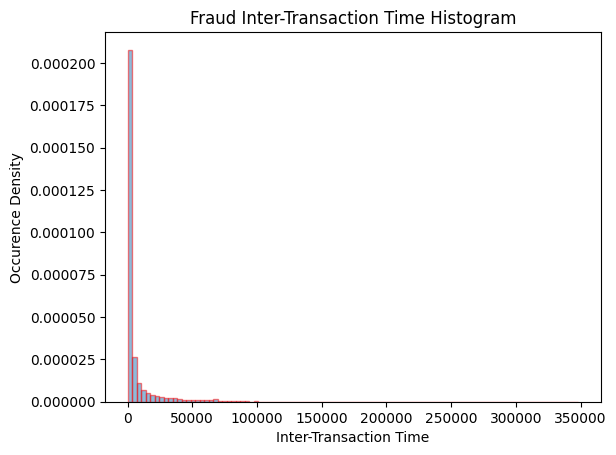

In [16]:
plt.hist(fraudtimedelts, label = 'is_fraud=1', density=True, bins=100, alpha=0.5, edgecolor='red')
plt.title('Fraud Inter-Transaction Time Histogram')
plt.xlabel('Inter-Transaction Time')
plt.ylabel('Occurence Density')
plt.show()

In [17]:
nofraudunixtimes = df.loc[df['is_fraud'] == 0, 'unix_time'].reset_index(drop=True)
timeA = nofraudunixtimes[1:].reset_index(drop=True)
timeB = nofraudunixtimes[0:-1].reset_index(drop=True)
nofraudtimedelts = timeA - timeB
mean = np.mean(nofraudtimedelts)
std = np.std(nofraudtimedelts)
print('no-fraud time delta mean: {}, std: {}'.format(mean, std))

no-fraud time delta mean: 34.27411759215343, std: 41.0282188977479


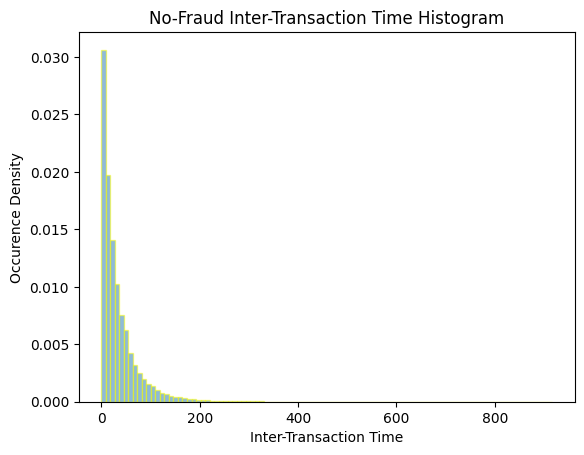

In [18]:
plt.hist(nofraudtimedelts, label = 'is_fraud=0', density=True, bins=100, alpha=0.5, edgecolor='yellow')
plt.title('No-Fraud Inter-Transaction Time Histogram')
plt.xlabel('Inter-Transaction Time')
plt.ylabel('Occurence Density')
plt.show()

**The histograms show fraud inter-transaction times being spaced much farther apart that no-fraud inter-transaction times.  The mean calculations show fraud occuring roughly every 1.75hrs, while non-fraudulent transactions occur every 34 seconds.**  

**Based on the standard deviation being larger than the mean, we can infer that neither distribution is gaussian.  This is evident in the histogram shapes.**  

**The non-gaussian distributions call for either a dataset transformation or a non-linear classification method.**

In [19]:
frauddatetimes = df.loc[df['is_fraud'] == 1, 'trans_date_trans_time'].reset_index(drop=True)
fraudsectimes = frauddatetimes.apply(lambda x:\
        x.hour * 3600 + x.minute * 60 + x.second)

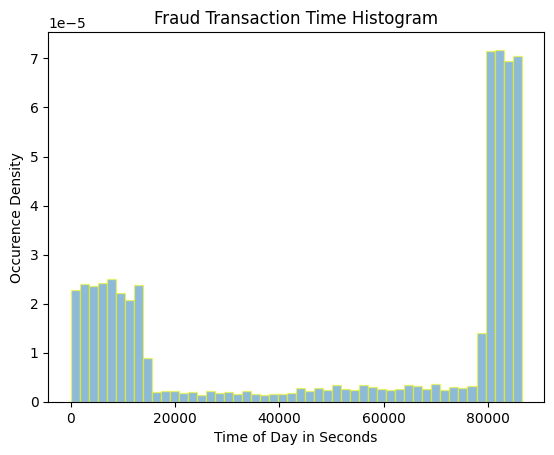

In [20]:
plt.hist(fraudsectimes, density=True, bins=50, alpha=0.5, edgecolor='yellow')
plt.title('Fraud Transaction Time Histogram')
plt.xlabel('Time of Day in Seconds')
plt.xticks(minor=True)
plt.ylabel('Occurence Density')
plt.show()

**The most likely time for fraud is around midnight.  This is evident in the histogram above, in which the occurences spike just before midnight (right side of plot), and just after midnight (left side of plot).**

**This may call for transaction time in the model to be split into 3 groups, one for each of the flat areas in the histogram.**

### 6) Is there a relationship between the distance between customer location (lat/lon) and merchant location (merch_lat/merch_lon) and fraudulent transactions?

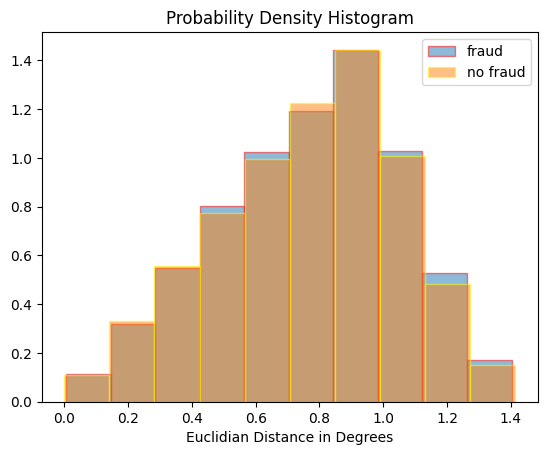

In [21]:
df['dist'] = np.sqrt(np.power(np.subtract(df['merch_lat'], df['lat']), 2) +\
                     np.power(np.subtract(df['merch_long'], df['long']), 2))
f1dist = df.loc[df['is_fraud'] == 1, 'dist'].to_numpy().reshape(-1, 1)
f0dist = df.loc[df['is_fraud'] == 0, 'dist'].to_numpy().reshape(-1, 1)

plt.hist(f1dist, label = 'fraud', density=True, alpha=0.5, edgecolor='red')
plt.hist(f0dist, label = 'no fraud', density=True, alpha=0.5, edgecolor='yellow')
plt.title('Probability Density Histogram')
plt.xlabel('Euclidian Distance in Degrees')
plt.legend()
plt.show()

**There seems to be no significant relationship between customer-merchant distance and fraud.  This is indicated by the near perfect overlap of the two histograms above.**  

**This may justify dropping the location features due to the lack of relationship with fraud.**

### 7) Are certain states, cities, and zip codes more susceptible to fraudulent transactions?

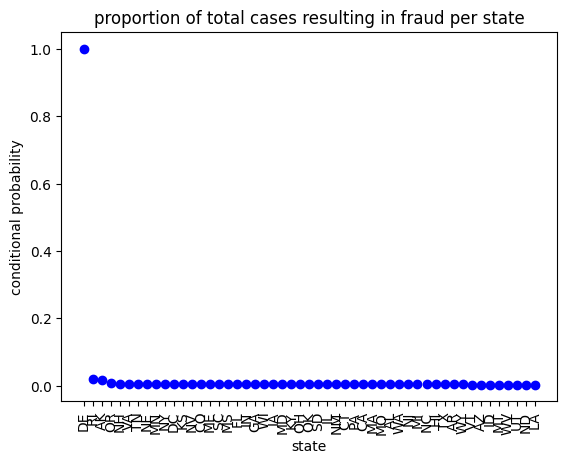

In [22]:
col = 'state'
valcors = (df.loc[df['is_fraud'] == 1, '{}'.format(col)].value_counts() /\
       df['{}'.format(col)].value_counts()).sort_values(ascending=False)
plt.scatter(valcors.index, valcors, c ="blue")
plt.title('proportion of total cases resulting in fraud per {}'.format(col))
plt.xlabel(col)
plt.xticks(rotation=90)
plt.ylabel('conditional probability')
plt.show()

**Delaware has a perfect conditional probability with fraud.  The remaining states have at least an order of magnitde lower conditional probability.**  

**The states should then be split into 2 groups for the model.**

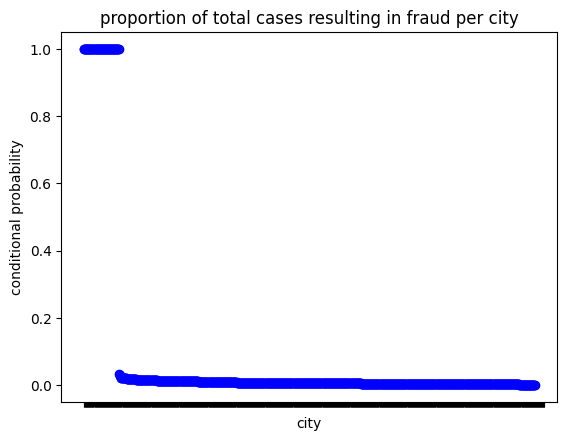

In [23]:
col = 'city'
valcors = (df.loc[df['is_fraud'] == 1, '{}'.format(col)].value_counts() /\
       df['{}'.format(col)].value_counts()).sort_values(ascending=False)
plt.scatter(valcors.index, valcors, c ="blue")
plt.title('proportion of total cases resulting in fraud per {}'.format(col))
plt.xlabel(col)
plt.xticks(valcors.index, labels="")
plt.ylabel('conditional probability')
plt.show()

**The plot shows a group of cities with perfect conditional probability with fraud, while the remaining have at least an order of mangitude lower conditional probability.**  

**The cities should then be split into 2 groups for the model.**

In [24]:
param = 'city'
valscounts = (df.loc[df['is_fraud'] == 1, '{}'.format(param)].value_counts() /\
       df['{}'.format(param)].value_counts()).sort_values(ascending=False) == 1.0
print(list(valscounts.loc[valscounts == True].index))

['Rice', 'Norfolk', 'Ridge Spring', 'East China', 'Queen Anne', 'Waukau', 'Pleasant Hill', 'Freeport', 'Phelps', 'Beacon', 'Gaines', 'Granbury', 'Greenport', 'Grenola', 'Brookfield', 'Guthrie', 'Orange Park', 'Oakton', 'North East', 'Downey', 'Wartburg', 'Wappapello', 'Springville', 'Buellton', 'Byesville', 'Vacaville', 'Chattanooga', 'Streator', 'Clarion', 'Claypool', 'Clinton', 'Walkertown', 'Coulee Dam', 'Craig', 'Senatobia', 'Seligman', 'Seattle', 'Crouse', 'Roland', 'West Frankfort', 'Grifton', 'Morven', 'Kirtland', 'Noblesville', 'Morrowville', 'Kaktovik', 'Karns City', 'Winnsboro', 'Mineral', 'Kirkwood', 'La Grande', 'Moss Point', 'Melville', 'Medford', 'Marshall', 'Las Vegas', 'Madisonville', 'Lexington', 'Lockhart', 'Angwin', 'Bruce', 'Mount Vernon', 'Irvington', 'Nicholson', 'Ashland', 'Hubbell', 'Nanuet', 'Mountain City', 'Wever', 'Isanti']


**The above cities are those with perfect conditional probability with fraud.**

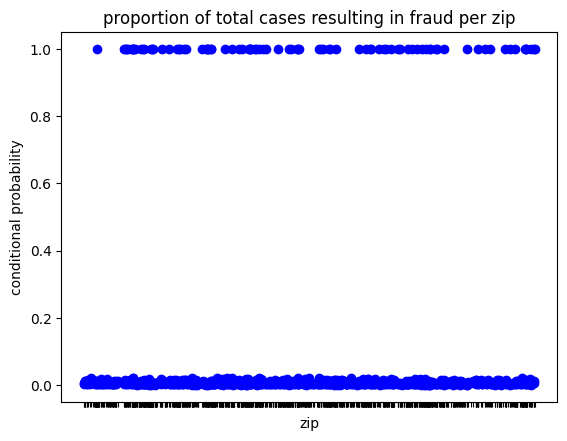

In [25]:
col = 'zip'
valcors = (df.loc[df['is_fraud'] == 1, '{}'.format(col)].value_counts() /\
       df['{}'.format(col)].value_counts()).sort_values(ascending=False)
plt.scatter(valcors.index, valcors, c ="blue")
plt.title('proportion of total cases resulting in fraud per {}'.format(col))
plt.xlabel(col)
plt.xticks(valcors.index, labels="")
plt.ylabel('conditional probability')
plt.show()

**Again we see a subset of zipcodes with high fraud conditional probability.**  

**The zip codes should then be split into 2 groups for the model.**

In [26]:
param = 'zip'
valscounts = (df.loc[df['is_fraud'] == 1, '{}'.format(param)].value_counts() /\
       df['{}'.format(param)].value_counts()).sort_values(ascending=False) == 1.0
print(list(valscounts.loc[valscounts == True].index))

[99921, 10533, 47842, 48054, 48436, 52658, 53045, 53559, 14532, 54980, 55040, 14141, 13795, 61364, 62896, 63966, 12508, 64080, 65745, 66958, 12207, 67346, 68375, 11944, 11763, 11747, 70065, 70447, 72135, 10954, 10553, 46510, 46060, 43723, 19947, 23523, 22204, 22124, 27051, 28033, 28119, 28412, 28530, 21657, 29129, 29180, 32065, 33762, 35211, 16041, 35896, 18446, 37307, 37411, 37683, 37887, 38668, 38915, 39562, 16428, 40502, 16214, 41101, 73044, 56367, 23117, 75246, 87417, 89109, 90240, 78644, 78208, 77038, 93427, 77027, 94508, 4032, 76048, 80019, 95688, 85201, 98105, 97850, 74108, 99116, 10018, 98118, 99747]


**The above zip codes are those with perfect conditional probability with fraud.**

### 8) What is the distribution of fraudulent and non-fraudulent transactions occurring for each day of the week (i.e., Sunday, Monday, etc.), each month of the year (i.e., January, February)?

In [27]:
frauddatetimes = df.loc[df['is_fraud'] == 1, 'trans_date_trans_time'].reset_index(drop=True)
frauddays = frauddatetimes.apply(lambda x: x.day_of_week)
fraudmonths = frauddatetimes.apply(lambda x: x.month)

In [28]:
nofrauddatetimes = df.loc[df['is_fraud'] == 0, 'trans_date_trans_time'].reset_index(drop=True)
nofrauddays = nofrauddatetimes.apply(lambda x: x.day_of_week)
nofraudmonths = nofrauddatetimes.apply(lambda x: x.month)

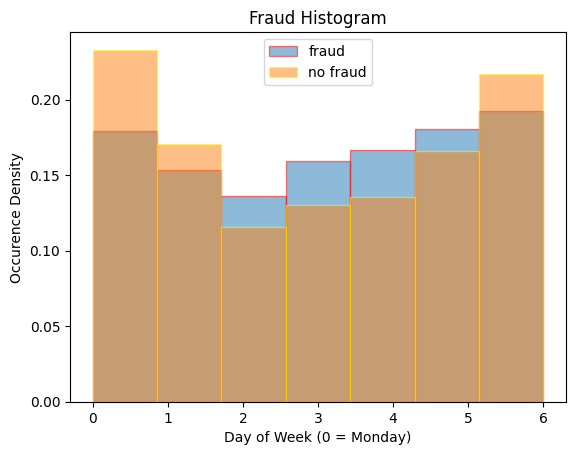

In [29]:
plt.hist(frauddays, label = 'fraud', bins = 7, density=True, alpha=0.5, edgecolor='red')
plt.hist(nofrauddays, label = 'no fraud', bins = 7, density=True, alpha=0.5, edgecolor='yellow')
plt.title('Fraud Histogram')
plt.xlabel('Day of Week (0 = Monday)')
plt.ylabel('Occurence Density')
plt.legend()
plt.show()

**While there tend to me more transactions at the beginning and end of each week, fraud seems to flatten the distribution.  For fraud there is an increase in occurences in the middle of the week and a decrease at the ends of the week.**  

**Sine/Cosine facetizing *trans_date_trans_time* allows for preservation of both the ordinality and cyclicality of day within week; this should be done for the model.**

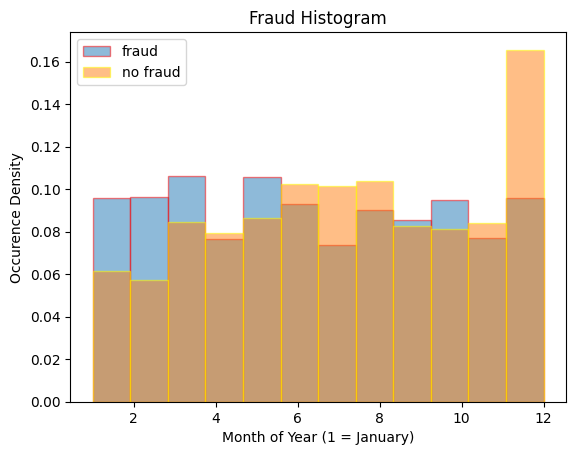

In [30]:
plt.hist(fraudmonths, label = 'fraud', bins = 12, density=True, alpha=0.5, edgecolor='red')
plt.hist(nofraudmonths, label = 'no fraud', bins = 12, density=True, alpha=0.5, edgecolor='yellow')
plt.title('Fraud Histogram')
plt.xlabel('Month of Year (1 = January)')
plt.ylabel('Occurence Density')
plt.legend()
plt.show()

**Fraud decreases over the summer months and drops leading into the Christmas/New Year holidays.  Fraud seems to increase in the months just following the holidays.**  

**Sine/Cosine facetizing *trans_date_trans_time* allows for preservation of both the ordinality and cyclicality of month within year; this should be done for the model.**

### 9) Compared to any other time of the year, how prevalent are fraudulent transactions during the holidays (11-30 to 12-31)? During post-holidays (1-1 to 2-28)? During the summer (05-24 to 09-01)?

In [31]:
frauddatetimes = df.loc[df['is_fraud'] == 1, 'trans_date_trans_time'].reset_index(drop=True)
frauddays = frauddatetimes.apply(lambda x: x.day)
fraudmonths = frauddatetimes.apply(lambda x: x.month)

In [32]:
fraudhol = ((frauddays == 30) & (fraudmonths == 11)) | (fraudmonths == 12)
fraudphol = fraudmonths.between(1, 2, inclusive = 'both')
fraudsum = ((frauddays.between(24, 31, inclusive = 'both')) & (fraudmonths == 5)) |\
        (fraudmonths.between(6, 8, inclusive = 'both')) |\
        ((fraudmonths == 9) & (frauddays == 1))

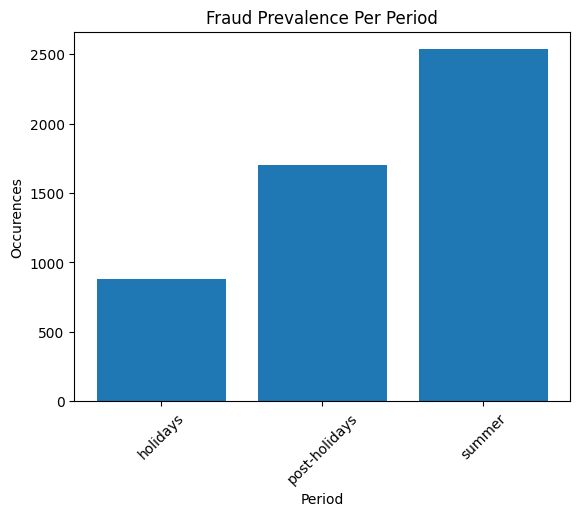

In [33]:
period = ['holidays', 'post-holidays', 'summer']
prevalence = [len(item.loc[item == True]) for item in\
              (fraudhol, fraudphol, fraudsum)]
plt.bar(period, prevalence)
plt.title('Fraud Prevalence Per Period')
plt.xlabel('Period')
plt.xticks(rotation=45)
plt.ylabel('Occurences')
plt.show()

**In agreement with the fraud/no-fraud histogram, there summer months show more fraud activity than the holidays.**  

**There seems to be no impact to the model or system from these results.**

### 10) Is there a relationship between between "city_pop" and incidence of fraud?

In [34]:
corrpopfraud = df['city_pop'].corr(df['is_fraud'])
fraudpop = df.loc[df['is_fraud'] == 1, 'city_pop'].reset_index(drop=True)
nofraudpop = df.loc[df['is_fraud'] == 0,'city_pop'].reset_index(drop=True)
meanpopfraud = np.mean(fraudpop)
meanpopnofraud = np.mean(nofraudpop)
print('correlation: {}\nmean pop fraud: {}\nmean pop nofraud: {}'.\
     format(corrpopfraud, meanpopfraud, meanpopnofraud))

correlation: 0.00032519441062587527
mean pop fraud: 89998.42296135116
mean pop nofraud: 88636.57928370913


**There is no significant correlation between *city_pop* and *is_fraud*.  The mean populations for each case are also nearly equal.  Hence I do not see a significant relationship between *city_pop* and *is_fraud*.**  

**The results may call for dropping the *city_pop* feature from the model.**

### 11) Are certain "job" types susceptible to fraudulent transactions?

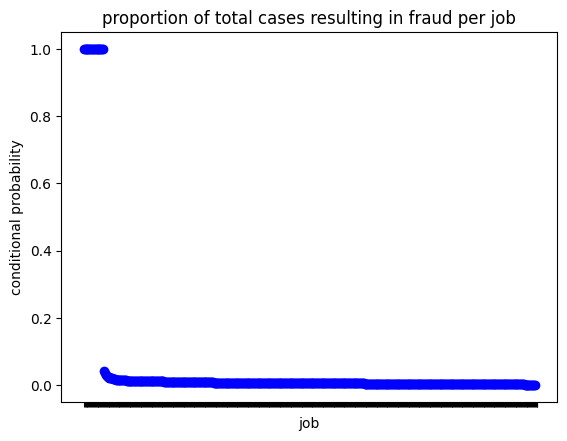

In [35]:
col = 'job'
valcors = (df.loc[df['is_fraud'] == 1, '{}'.format(col)].value_counts() /\
       df['{}'.format(col)].value_counts()).sort_values(ascending=False)
plt.scatter(valcors.index, valcors, c ="blue")
plt.title('proportion of total cases resulting in fraud per {}'.format(col))
plt.xlabel(col)
plt.xticks(valcors.index, labels="")
plt.ylabel('conditional probability')
plt.show()

**The plot shows a group of jobs with perfect conditional probability with fraud, while the remaining have at least an order of mangitude lower conditional probability.**  

**The jobs should then be split into 2 groups for the model.**

In [36]:
param = 'job'
valscounts = (df.loc[df['is_fraud'] == 1, '{}'.format(param)].value_counts() /\
       df['{}'.format(param)].value_counts()).sort_values(ascending=False) == 1.0
print(list(valscounts.loc[valscounts == True].index))

['Homeopath', 'Accountant, chartered', 'Forest/woodland manager', 'Software engineer', 'Ship broker', 'Armed forces technical officer', 'Dancer', 'Sales promotion account executive', 'Air traffic controller', 'Broadcast journalist', 'Contracting civil engineer', 'Industrial buyer', 'Information officer', 'Engineer, water', 'Engineer, site', 'Careers adviser', 'Personnel officer', 'Veterinary surgeon', 'Operational investment banker', 'Legal secretary', 'Warehouse manager', 'Solicitor']


**The jobs with perfect conditional probability with fraud are listed above.**

### 12) Are there certain days over the Thanksgiving-New Year holidays in which fraud is more prevalent?

In [37]:
frauddatetimes = df.loc[df['is_fraud'] == 1, 'trans_date_trans_time'].reset_index(drop=True)
frauddays = frauddatetimes.apply(lambda x: x.day)
fraudmonths = frauddatetimes.apply(lambda x: x.month)
fraudhol = (((frauddays.between(20, 30, inclusive = 'both')) & (fraudmonths == 11)) |\
        ((frauddays.between(1, 2, inclusive = 'both')) & (fraudmonths == 1)) |\
        (fraudmonths == 12)).rename('holiday_period')

frauddayshol = pd.concat([frauddatetimes, fraudhol], axis=1)
frauddayshol = frauddayshol.loc[frauddayshol['holiday_period'] == True]

frauddays = frauddayshol['trans_date_trans_time'].apply(lambda x: x.day).astype(str)
fraudmonths = frauddayshol['trans_date_trans_time'].apply(lambda x: x.month).astype(str)
frauddayshol['mo_day'] = fraudmonths.str.cat(frauddays, join='outer', sep='-')

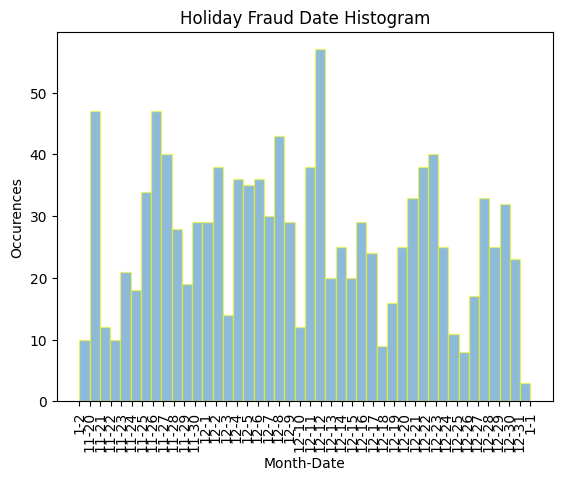

In [38]:
numdates = len(frauddayshol['mo_day'].unique())
plt.hist(frauddayshol['mo_day'], bins=numdates, alpha=0.5, edgecolor='yellow')
plt.title('Holiday Fraud Date Histogram')
plt.xlabel('Month-Date')
plt.xticks(rotation=90)
plt.ylabel('Occurences')
plt.show()

**There seem to be low fraud occurences on Christmas Day and New Years Day.  Otherwise, the only discernible pattern seems to be embedded in the weekly cycle of days.**  

**The model may allow a new feature indicating whether it is Christmas Day or New Years Day or not.**

### 13) Over the first 2 months after the holidays, are there certain days in which fraud is more prevalent?

In [39]:
frauddatetimes = df.loc[df['is_fraud'] == 1, 'trans_date_trans_time'].reset_index(drop=True)
frauddays = frauddatetimes.apply(lambda x: x.day)
fraudmonths = frauddatetimes.apply(lambda x: x.month)
fraudphol = (fraudmonths.between(1, 2, inclusive = 'both')).rename('holiday_period')

frauddaysphol = pd.concat([frauddatetimes, fraudphol], axis=1)
frauddaysphol = frauddaysphol.loc[frauddaysphol['holiday_period'] == True]

frauddays = frauddaysphol['trans_date_trans_time'].apply(lambda x: x.day).astype(str)
fraudmonths = frauddaysphol['trans_date_trans_time'].apply(lambda x: x.month).astype(str)
frauddaysphol['mo_day'] = fraudmonths.str.cat(frauddays, join='outer', sep='-')

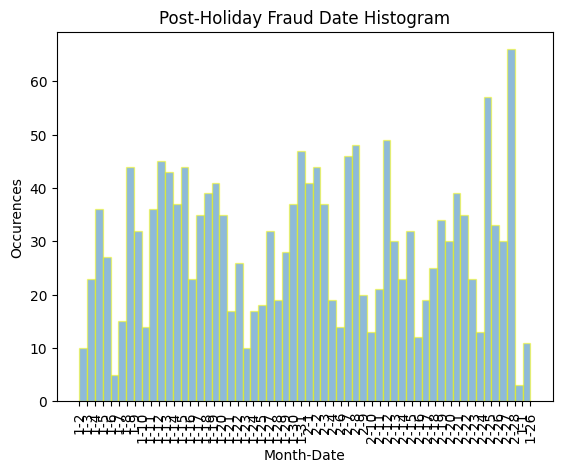

In [40]:
numdates = len(frauddaysphol['mo_day'].unique())
plt.hist(frauddaysphol['mo_day'], bins=numdates, alpha=0.5, edgecolor='yellow')
plt.title('Post-Holiday Fraud Date Histogram')
plt.xlabel('Month-Date')
plt.xticks(rotation=90)
plt.ylabel('Occurences')
plt.show()

**During the most fraud-dense part of the year, there seems to be no discernible pattern in fraud occurences.  It is notable, however, that the last days of the month have an increase in fraud.  See 31JAN (1-31) and 28FEB (2-28).**  
  
**The model may allow a new feature indicating whether it is the end of the month for months aside from NOV-DEC.**

### 14) During peak fraud times, what is the distribution of time between fraudulent transactions?

In [41]:
frauddatetimes = df.loc[df['is_fraud'] == 1, ['trans_date_trans_time', 'unix_time']].\
reset_index(drop=True)
frauddatetimes['fraud_sec'] = frauddatetimes['trans_date_trans_time'].apply(lambda x:\
        x.hour * 3600 + x.minute * 60 + x.second)

In [42]:
mask = ((frauddatetimes['fraud_sec'].between(0, 15000, inclusive = 'both')) |\
        (frauddatetimes['fraud_sec'].between(78300, 86700, inclusive = 'both')))
frauddatetimes = frauddatetimes.loc[mask].reset_index(drop=True)


In [43]:
fraudunix = frauddatetimes['unix_time']
timeA = fraudunix[1:].reset_index(drop=True)
timeB = fraudunix[0:-1].reset_index(drop=True)
fraudtimedelts = timeA - timeB
mean = np.mean(fraudtimedelts)
std = np.std(fraudtimedelts)
print('peak fraud time delta mean: {}, std: {}'.format(mean, std))

peak fraud time delta mean: 7599.758662762323, std: 21381.605947077842


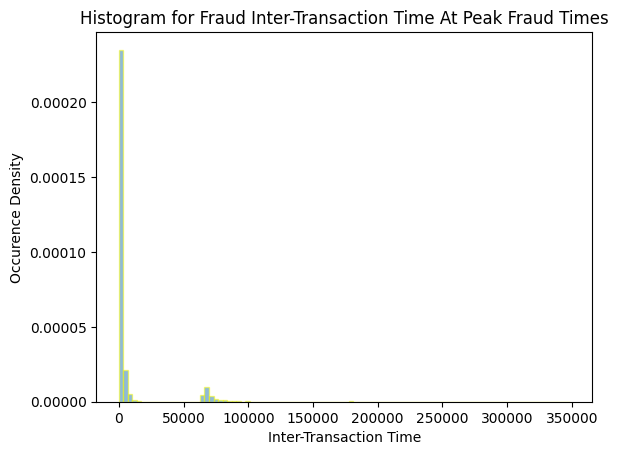

In [44]:
plt.hist(fraudtimedelts, density=True, bins=100, alpha=0.5, edgecolor='yellow')
plt.title('Histogram for Fraud Inter-Transaction Time At Peak Fraud Times')
plt.xlabel('Inter-Transaction Time')
plt.ylabel('Occurence Density')
plt.show()

**This histogram only accounts for fraud transactions occuring in the peaks before and after midnight.  The distribution seems bimodal, with most occurences happening in a short interval, and the remaining happening closer to a full day between transactions.**  

**There does not seem to be model or system impact from these results.**

### 15) During off-peak fraud times, what is the distribution of time between fraudulent transactions?

In [45]:
frauddatetimes = df.loc[df['is_fraud'] == 1, ['trans_date_trans_time', 'unix_time']].\
reset_index(drop=True)
frauddatetimes['fraud_sec'] = frauddatetimes['trans_date_trans_time'].apply(lambda x:\
        x.hour * 3600 + x.minute * 60 + x.second)

In [46]:
mask = frauddatetimes['fraud_sec'].between(15000, 78300, inclusive = 'neither')
frauddatetimes = frauddatetimes.loc[mask].reset_index(drop=True)


In [47]:
fraudunix = frauddatetimes['unix_time']
timeA = fraudunix[1:].reset_index(drop=True)
timeB = fraudunix[0:-1].reset_index(drop=True)
fraudtimedelts = timeA - timeB
mean = np.mean(fraudtimedelts)
std = np.std(fraudtimedelts)
print('off-peak fraud time delta mean: {}, std: {}'.format(mean, std))

off-peak fraud time delta mean: 42815.63799036476, std: 56543.656875355875


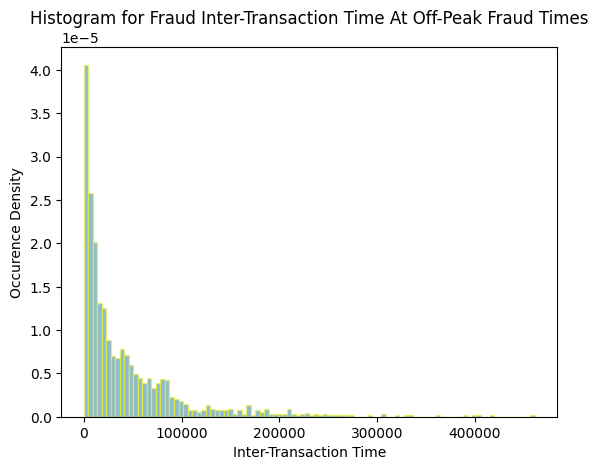

In [48]:
plt.hist(fraudtimedelts, density=True, bins=100, alpha=0.5, edgecolor='yellow')
plt.title('Histogram for Fraud Inter-Transaction Time At Off-Peak Fraud Times')
plt.xlabel('Inter-Transaction Time')
plt.ylabel('Occurence Density')
plt.show()

**Off peak fraud inter-transaction times have a comparable mean and standard deviation with peak times, but the distribution is clearly non-bimodal.**

**There does not seem to be model or system impact from these results.**

### CONCLUSION

We drop the following columns due to the analysis above.  They are either unique to each transaction, or show no relationship with fraud.

*'Unnamed: 0', 'cc_num', 'merchant', 'first', 'last', 'street', 'trans_num', 'unix_time', 'merch_lat', 'lat','merch_long', 'long', 'city_pop'*